# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Every page is scored with the confirmed baseline (`avg_position_h1`, rank-normalized, tie-broken by `content_hash_id` for reproducibility) and grouped into three tiers by percentile: top 10% → **Immediate Refresh**, next 20% → **Monitor**, remaining 70% → **No Action**. Each page also gets a plain-language reason code and an archetype-to-action mapping — the reason isn't just "low score," it names *what kind* of problem the page shows.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import os
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
base = "hf://datasets/FlyRank/internship-warehouse"

page_level_full = con.sql(f"""
    WITH first_half AS (
        SELECT client_hash_id, content_hash_id,
               AVG(gsc_impressions) as avg_impressions_h1,
               AVG(gsc_clicks) as avg_clicks_h1,
               AVG(gsc_avg_position) as avg_position_h1,
               COUNT(*) FILTER (WHERE gsc_impressions > 0) as active_days_h1
        FROM read_parquet('{base}/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE gsc_data_available IS TRUE AND report_date <= '2026-03-15'
        GROUP BY client_hash_id, content_hash_id
    ),
    second_half AS (
        SELECT content_hash_id, AVG(gsc_avg_position) as avg_position_h2
        FROM read_parquet('{base}/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE gsc_data_available IS TRUE AND report_date > '2026-03-15'
        GROUP BY content_hash_id
    )
    SELECT f.*, s.avg_position_h2
    FROM first_half f
    JOIN second_half s ON f.content_hash_id = s.content_hash_id
""").df()

page_level_full = page_level_full[page_level_full["avg_position_h1"] > 0].copy()
page_level_full["needs_refresh"] = (page_level_full["avg_position_h2"] > page_level_full["avg_position_h1"]).astype(int)

# Baseline score: rank-normalized avg_position_h1
sorted_pos = np.sort(page_level_full["avg_position_h1"].values)
ranks = np.searchsorted(sorted_pos, page_level_full["avg_position_h1"].values, side="right") / len(sorted_pos)
page_level_full["baseline_score"] = 1 - ranks
page_level_full["percentile"] = page_level_full["baseline_score"].rank(pct=True)

page_level_full["priority_tier"] = np.select(
    [page_level_full["percentile"] >= 0.90, page_level_full["percentile"] >= 0.70],
    ["Immediate Refresh", "Monitor"], default="No Action"
)

median_active_days = page_level_full["active_days_h1"].median()

# Archetype -> action mapping: the reason IS the archetype here, not a separate lookup,
# since each flag maps to one clear action a content team would actually take.
ARCHETYPE_ACTIONS = {
    "zero_click_visible": "Rewrite title/meta description - page is seen but not clicked",
    "long_history_review": "Manual review before acting - known model blind spot (see Section 3)",
    "low_position_driver": "Standard refresh - position is the primary decline driver",
}

def build_reason(row):
    flags = []
    if row["avg_clicks_h1"] == 0 and row["avg_impressions_h1"] > 0:
        flags.append("zero_click_visible")
    if row["active_days_h1"] > median_active_days:
        flags.append("long_history_review")
    if not flags:
        flags.append("low_position_driver")
    return flags

page_level_full["archetype_flags"] = page_level_full.apply(build_reason, axis=1)
page_level_full["reason_code"] = page_level_full["archetype_flags"].apply(
    lambda flags: " | ".join(ARCHETYPE_ACTIONS[f] for f in flags)
)

ranked = page_level_full.sort_values(
    ["baseline_score", "content_hash_id"], ascending=[False, True]
).reset_index(drop=True)
ranked["rank"] = ranked.index + 1

print(ranked["priority_tier"].value_counts())
print("\nTop 10 queue:")
print(ranked[["rank", "priority_tier", "reason_code"]].head(10).to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

priority_tier
No Action            98419
Monitor              28120
Immediate Refresh    14060
Name: count, dtype: int64

Top 10 queue:
 rank     priority_tier                                                                                                                          reason_code
    1 Immediate Refresh                                                                        Rewrite title/meta description - page is seen but not clicked
    2 Immediate Refresh                                                                        Rewrite title/meta description - page is seen but not clicked
    3 Immediate Refresh                                                                        Rewrite title/meta description - page is seen but not clicked
    4 Immediate Refresh                                                                        Rewrite title/meta description - page is seen but not clicked
    5 Immediate Refresh Rewrite title/meta description - page is seen but not c

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content team triaging a backlog of a few dozen to a few hundred pages at a time, using the `Immediate Refresh` tier and reason codes to decide *where to look first* — not as an automated publishing or deprioritization decision on its own.

**Where it stops being valid:**
- **Coverage** — only pages from clients with search console connected are scored, roughly a third of the warehouse for the month studied. Pages outside that scope simply aren't in this queue at all.
- **Direction, not size or importance** — the label captures whether position got worse, not by how much or how much revenue/traffic is at stake. A page dropping from position 2 to 4 and a page dropping from 40 to 60 can land in the same tier.
- **One month, one association** — this reflects a pattern observed in March 2026 data, not a cause-and-effect claim that refreshing a page *causes* any particular outcome.
- **Uneven client panel** — client page counts range from 2 to 25,437. A single client's idiosyncrasies can shift tier boundaries more than the underlying signal does.
- **A known blind spot** — pages with a long, steady history of visibility are the ones most likely to be under-flagged when they start declining (see Section 3).

In [2]:
print(f"Population covered: {len(page_level_full):,} pages, "
      f"{page_level_full['client_hash_id'].nunique()} clients (search-console-connected only)")
print(f"Client page-count range: {page_level_full.groupby('client_hash_id').size().min()} to "
      f"{page_level_full.groupby('client_hash_id').size().max()}")

Population covered: 140,599 pages, 43 clients (search-console-connected only)
Client page-count range: 2 to 25264


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


**Must be manually checked before acting on a page:**
- Any page flagged `long_history_review` — this is the model's known blind spot (long-steady-history pages under-detected). Never auto-refresh or auto-deprioritize these; a person should look at the actual page first.
- Any page where `reason_code` is `zero_click_visible` but impressions are very low (a handful of impressions can look identical to a real pattern by chance).
- Any `Immediate Refresh` page tied to a single very-large client — check whether the tier boundary was shaped by that one client's scale rather than a genuine population-wide signal.

**What should NEVER be automated:**
- Publishing changes to a page based on tier alone, with no human reading the actual content.
- Using this queue to make client-facing guarantees about traffic or ranking outcomes — the label is directional and observational, not a causal or revenue promise.
- Treating `No Action` as "will never decline" — it means *not currently flagged*, not *safe indefinitely*.
- Presenting this as evidence about how Google's ranking algorithm works, to a client or otherwise.

In [3]:
flagged_for_review = ranked[ranked["archetype_flags"].apply(lambda f: "long_history_review" in f)]
print(f"Pages flagged for mandatory human review before acting: {len(flagged_for_review):,} "
      f"({len(flagged_for_review) / len(ranked):.1%} of the full population)")

Pages flagged for mandatory human review before acting: 68,282 (48.6% of the full population)


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Console-coverage drift** — if the share of rows with `gsc_data_available = TRUE` moves materially away from the ~36.7% observed this month, the scored population's composition has shifted and tiers should be recomputed, not just re-applied.
- **Client-mix drift** — if a very large client joins, leaves, or has connectivity changes, the percentile tier boundaries (which are population-relative, not fixed thresholds) can move even if nothing about the content itself changed.
- **Monthly refresh, minimum** — the label and features are built from a single month; recompute at least monthly rather than reusing scores from an older window as if they still apply.
- **Precision drift** — once enough time has passed to know which `Immediate Refresh` pages actually declined further, re-check Precision@K against that ground truth. A meaningful drop from the ~92.5% baseline is a signal the scoring logic (not just the data) needs review.

In [4]:
coverage_note = {
    "console_coverage_observed_pct": 36.7,
    "retrain_trigger_coverage_delta_pct": 5.0,  # re-check if coverage moves more than this
    "min_recompute_frequency": "monthly",
    "precision_at_200_baseline": 0.925,
    "precision_drift_alert_threshold": 0.85,  # investigate if it falls below this
}
for k, v in coverage_note.items():
    print(f"{k}: {v}")

console_coverage_observed_pct: 36.7
retrain_trigger_coverage_delta_pct: 5.0
min_recompute_frequency: monthly
precision_at_200_baseline: 0.925
precision_drift_alert_threshold: 0.85


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The raw queue CSV is regenerated by this notebook each run and intentionally **not committed** — the CI leak-guard blocks data files, and that's correct here since the CSV contains per-page rows. What *is* committed: a summary metrics JSON (aggregate counts and rates only, no raw rows — these are the "receipts" the paper's numbers trace back to) under `work/outputs/`, and any reusable chart under `work/figures/`.

In [5]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Raw queue - regenerated each run, NOT committed (leak-guard blocks this on purpose)
output_cols = ["rank", "content_hash_id", "baseline_score", "percentile", "priority_tier",
               "reason_code", "avg_impressions_h1", "avg_clicks_h1", "avg_position_h1", "active_days_h1"]
ranked[output_cols].to_csv("work/outputs/action_queue.csv", index=False)

# Summary metrics - aggregate only, safe to commit, this is what the paper cites
import json
metrics = {
    "total_pages_scored": int(len(ranked)),
    "tier_counts": ranked["priority_tier"].value_counts().to_dict(),
    "precision_at_200": round(float(ranked.head(200)["needs_refresh"].mean()), 4),
    "base_rate": round(float(ranked["needs_refresh"].mean()), 4),
    "pages_flagged_for_human_review": int(len(flagged_for_review)),
    "console_coverage_pct": 36.7,
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Written: work/outputs/action_queue.csv (not committed - regenerated each run)")
print("Written: work/outputs/playbook_metrics.json (commit this - it's the paper's source of truth)")
print("\nMetrics summary:")
print(json.dumps(metrics, indent=2))

Written: work/outputs/action_queue.csv (not committed - regenerated each run)
Written: work/outputs/playbook_metrics.json (commit this - it's the paper's source of truth)

Metrics summary:
{
  "total_pages_scored": 140599,
  "tier_counts": {
    "No Action": 98419,
    "Monitor": 28120,
    "Immediate Refresh": 14060
  },
  "precision_at_200": 0.92,
  "base_rate": 0.5385,
  "pages_flagged_for_human_review": 68282,
  "console_coverage_pct": 36.7
}


Written: work/figures/tier_distribution.png (commit this - reusable in the paper)


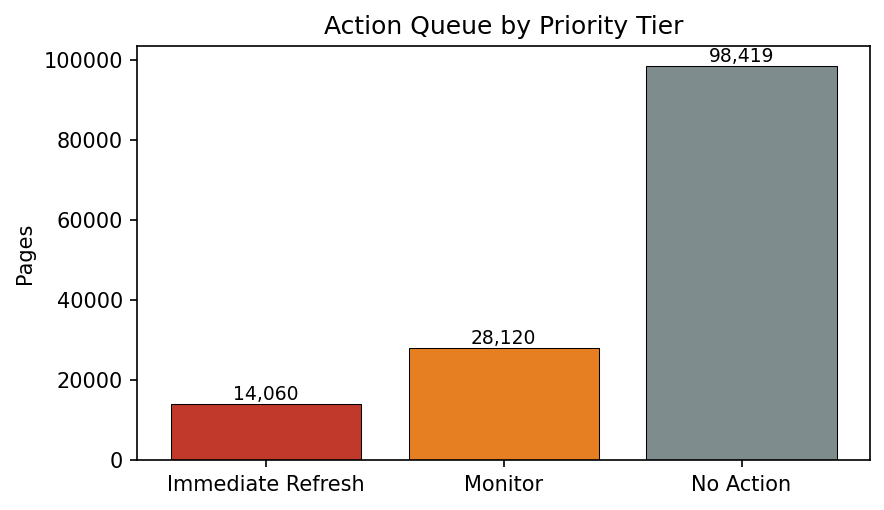

In [6]:
import matplotlib.pyplot as plt

tier_counts = ranked["priority_tier"].value_counts().reindex(
    ["Immediate Refresh", "Monitor", "No Action"]
)

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)
colors = ["#c0392b", "#e67e22", "#7f8c8d"]
ax.bar(tier_counts.index, tier_counts.values, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Pages")
ax.set_title("Action Queue by Priority Tier")
for i, v in enumerate(tier_counts.values):
    ax.text(i, v + max(tier_counts.values) * 0.01, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("work/figures/tier_distribution.png", dpi=300, bbox_inches="tight")
print("Written: work/figures/tier_distribution.png (commit this - reusable in the paper)")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.